**Name**: Meenakshi Sangeeth 

**Registration Number**: 240905630

**Section:** PG

**Roll Number:** 34

In [87]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [88]:
# Loading the dataset with appropriate encoding
df = pd.read_csv('Hypermart.csv', encoding='ISO-8859-1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [89]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


# Data Cleaning

In [90]:
# 1. Are there any duplicate or unnecessary attributes in the dataset? If so, identify and remove them to optimize data analysis.

df.drop(columns=['Row ID','Postal Code'], inplace=True)
df.drop_duplicates(inplace=True)

In [68]:
# 2. Identify if the dataset contains any missing data, inconsistencies in the values for a given attribute

# Identify missing values
print("Missing Values:\n", df.isnull().sum())

# Check for inconsistencies in categorical values
for col in ['Region', 'Category', 'Sub-Category', 'Segment', 'Ship Mode']:
    print(f"\nUnique values in {col}:")
    print(df[col].unique())


Missing Values:
 Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Unique values in Region:
['South' 'West' 'Central' 'East']

Unique values in Category:
['Furniture' 'Office Supplies' 'Technology']

Unique values in Sub-Category:
['Bookcases' 'Chairs' 'Labels' 'Tables' 'Storage' 'Furnishings' 'Art'
 'Phones' 'Binders' 'Appliances' 'Paper' 'Accessories' 'Envelopes'
 'Fasteners' 'Supplies' 'Machines' 'Copiers']

Unique values in Segment:
['Consumer' 'Corporate' 'Home Office']

Unique values in Ship Mode:
['Second Class' 'Standard Class' 'First Class' 'Same Day']


In [69]:
# To remove outliers using IQR
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    filtered_df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    return filtered_df

for col in ['Sales', 'Profit', 'Discount', 'Quantity']:
    df = remove_outliers_iqr(df, col)


In [70]:
df.describe()

,Sales,Quantity,Discount,Profit
count,6705.000000,6705.000000,6705.000000,6705.000000
mean,66.759993,3.367934,0.096944,11.239461
std,84.432109,1.864171,0.105461,13.010715
min,0.990000,1.000000,0.000000,-27.715800
25%,14.850000,2.000000,0.000000,3.210000
50%,34.384000,3.000000,0.000000,7.783200
75%,82.260000,4.000000,0.200000,17.182800
max,496.860000,9.000000,0.500000,50.584800


# Exploratory data analysis using Numpy, Pandas, Matplotlib and Seaborn

In [72]:
# Add whitegrids to plots
sns.set(style='whitegrid')

## Data distribution and Trends

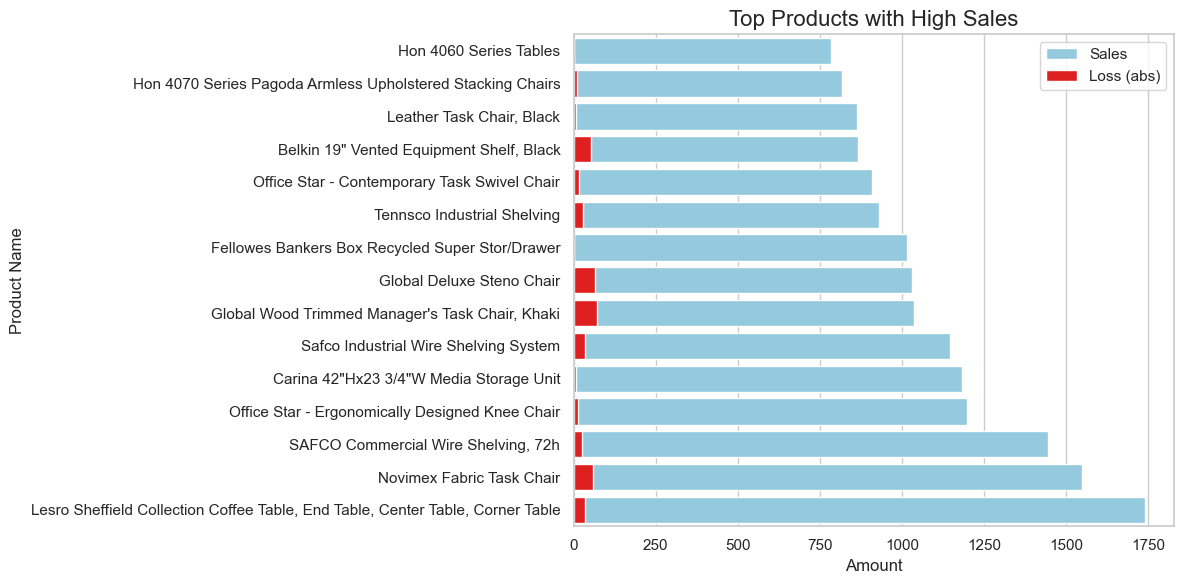

In [74]:
# Which Products have high sales but low or negative profit margins?

product_stats = df.groupby('Product Name')[['Sales', 'Profit']].sum()
negative_profit_products = product_stats[product_stats['Profit'] < 0]
top_negative = negative_profit_products.nlargest(15, 'Sales').sort_values('Sales')
top_negative['Abs_Profit'] = top_negative['Profit'].abs()

plt.figure(figsize=(12, 6))
sns.barplot(x='Sales', y=top_negative.index, data=top_negative, color='skyblue', label='Sales')
sns.barplot(x='Abs_Profit', y=top_negative.index, data=top_negative, color='red', label='Loss (abs)')
plt.title('Top Products with High Sales', fontsize=16)
plt.xlabel('Amount')
plt.ylabel('Product Name')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


The horizontal bar chart titled "Top Products with High Sales" compares sales and losses for the top-performing products. 
- WD My Passport Ultra 1TB Portable External Hard Drive shows the highest sales among the listed products but also a noticeable amount of loss (represented in red).
- Plantronics MX500C Headset, Motorola HK250 Universal Bluetooth Headset, and Rogers Deluxe File Chest also report significant sales along with visible loss bars.
- These patterns suggest that some tech-related products and certain storage solutions are driving revenue but may be hurting profitability—potentially due to discounts, high return rates, or low margins.

While certain products achieve impressive sales figures, some tech-related products and storage items incur noticeable losses potentially due to discounts, high return rates, or low margins. Businesses should carefully evaluate pricing, cost structures, and promotional strategies for these high-revenue but low-margin products to avoid long-term financial inefficiencies

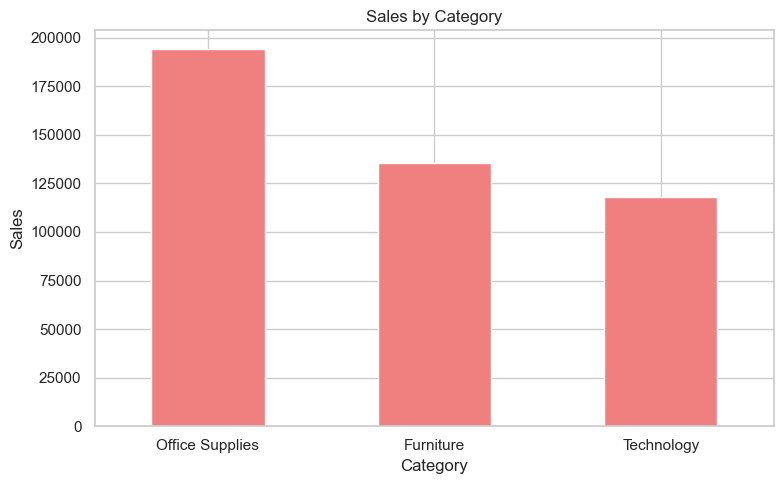

In [75]:
# Which Product Categories have the highest sales volume?

category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
category_sales.plot(kind='bar', title='Sales by Category', color='lightcoral')
plt.ylabel('Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The second vertical bar chart titled "Sales by Category" clearly shows the sales distribution across the three main product categories:

- Office Supplies leads by a significant margin, with over 110,000 in sales.
- Technology follows but at roughly half the volume of Office Supplies.
- Furniture has the lowest total sales among the three

Office Supplies is the most in-demand category, likely due to its broad utility and frequency of purchase. This suggests a stable revenue stream. However, Technology, despite lower total sales, may offer higher-margin opportunities depending on the product

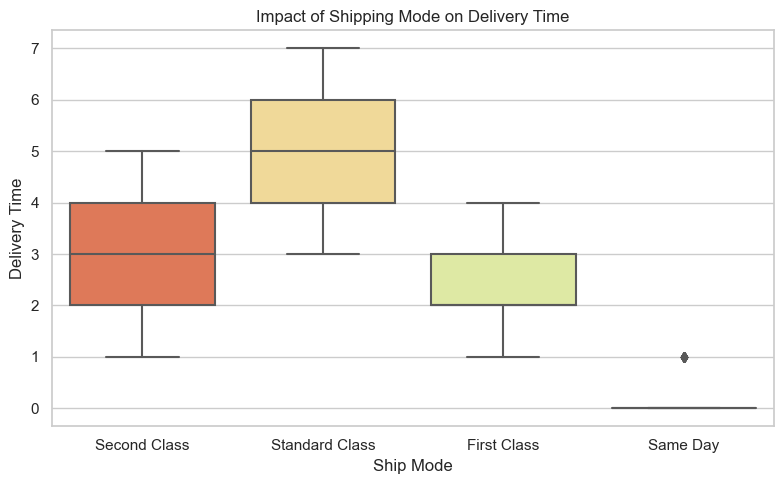

In [91]:
# Does the Shipping Mode impact Order Delivery Time?

df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
df['Delivery Time'] = (df['Ship Date'] - df['Order Date']).dt.days

plt.figure(figsize= (8, 5))
sns.boxplot(data=df, x='Ship Mode', y='Delivery Time', palette='Spectral')
plt.title('Impact of Shipping Mode on Delivery Time')
plt.ylabel('Delivery Time')
plt.tight_layout()
plt.show()


The third box plot, "Impact of Shipping Mode on Delivery Time", visualizes how different shipping methods affect delivery speed:

- Same Day shipping (green) results in the fastest delivery, typically 1–2 days.
- First Class and Standard Class modes (yellow and orange) have wider spread in delivery times, ranging from 2–6 days.
- Second Class (reddish) generally has longer delivery times, often between 3–5 days.

Shipping mode significantly influences delivery performance. Customers opting for faster delivery (e.g., Same Day) experience more consistent and rapid service, which could boost customer satisfaction. Businesses might consider promoting premium shipping for urgent orders or adjusting expectations based on mode selection

## Customer Segmentation & Regional Insights

<Figure size 800x500 with 0 Axes>

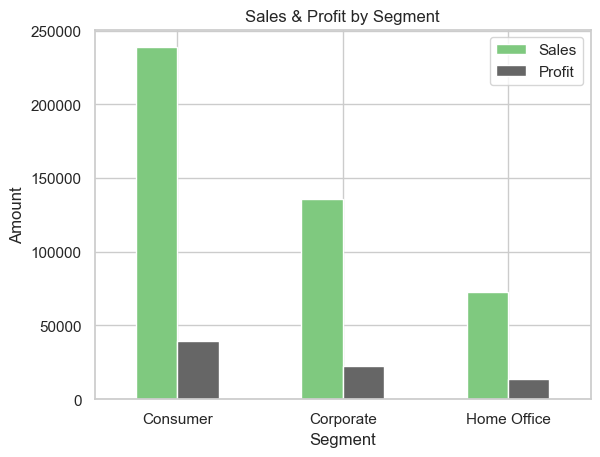

In [79]:
# Which Customer Segment (Consumer, Corporate, Home Office) generates the highest Sales and Profit?

segment_stats = df.groupby('Segment')[['Sales', 'Profit']].sum()
plt.figure(figsize= (8, 5))
segment_stats.plot(kind='bar', title='Sales & Profit by Segment', colormap='Accent')
plt.ylabel('Amount')
plt.xticks(rotation=0)
plt.show()

This bar chart compares total sales and profits across three customer segments: Consumer, Corporate, and Home Office.
- Consumer segment leads with the highest sales and profits.
- Corporate shows strong sales but notably lower profits, suggesting tighter margins.
- Home Office lags behind in both metrics, contributing the least revenue and profit

Consumer customers are the most valuable in terms of both revenue and profit. Corporate clients generate substantial sales but may require better cost management or pricing strategies to enhance profitability. Targeted approaches to optimize returns from Corporate and Home Office segments could lead to improved overall performance

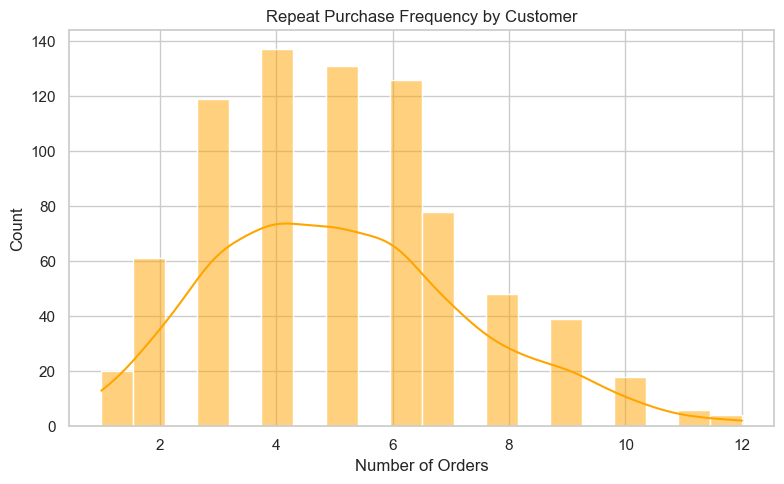

In [80]:
# What is the repeat purchase behaviour of customers in each segment?

repeat_counts = df.groupby('Customer ID')['Order ID'].nunique()

plt.figure(figsize=(8, 5))
sns.histplot(repeat_counts, bins=20, kde=True, color='orange')
plt.title('Repeat Purchase Frequency by Customer')
plt.xlabel('Number of Orders')
plt.tight_layout()
plt.show()


This histogram with a distribution curve highlights how frequently customers return to place new orders.

- Most customers place between 3 to 6 repeat orders, indicating moderate engagement.
- The frequency sharply drops after 7 orders, with very few high-volume repeat customers.

Customer loyalty is evident in the mid-range, suggesting a stable customer base. However, there’s potential to convert moderate repeat customers into high-value ones through loyalty incentives, tailored communication, and improved post-purchase experiences.


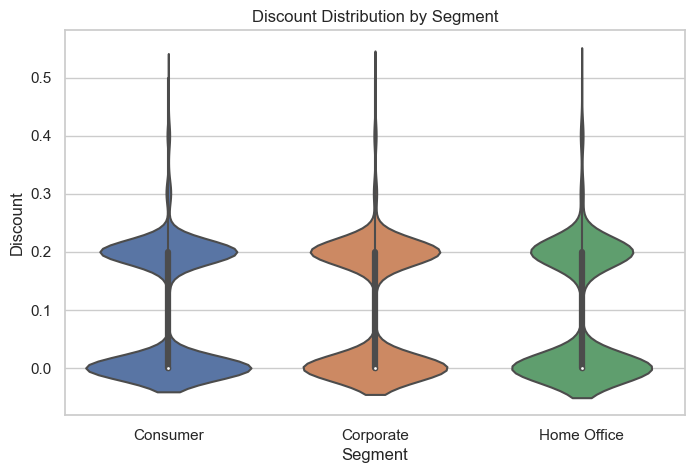

In [81]:
# Do certain segments respond better to Discounts?

plt.figure(figsize= (8, 5))
sns.violinplot(x='Segment', y='Discount', data=df)
plt.title('Discount Distribution by Segment')
plt.show()


This violin plot displays how discounts are distributed among the three segments.
- All segments show a similar core distribution: heavy concentration around 0% and 0.2.
- Slight variations exist—Home Office shows slightly more spread, hinting at higher discount variability.
- Corporate and Consumer follow a more uniform pattern, with fewer extremes.

Discount strategies appear fairly consistent across segments, but the slight variance suggests Home Office may be more price-sensitive. Businesses can test personalized discount models for different segments to improve conversion without eroding margins

## Growth Opportunities & Market Expansion

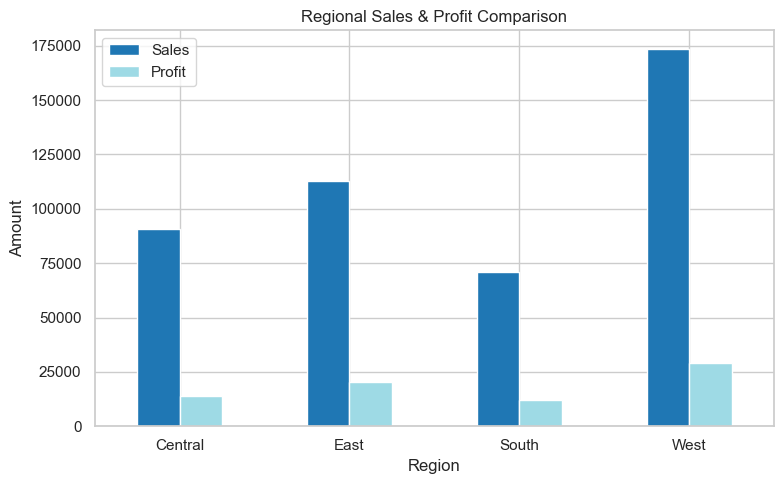

In [83]:
# Can pricing strategies be adjusted based on Regional Demand?

region_stats = df.groupby('Region')[['Sales', 'Profit']].sum()

region_stats.plot(kind='bar', colormap='tab20', figsize=(8, 5))
plt.title('Regional Sales & Profit Comparison')
plt.ylabel('Amount')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


The bar chart compares total sales and profits across four regions: Central, East, South, and West.
- The West region dominates in both sales and profit, with over 70,000 in sales and the highest profit margins.
- The South region shows the lowest performance in both aspects, with notably smaller profit margins.
- Central and East are mid-performers, with the East slightly ahead in profit.

The West is a strong performer and could serve as a benchmark for other regions. The South, on the other hand, shows signs of stagnation and may require strategic interventions—like improved promotions, optimized pricing, or localized campaigns—to boost its contribution

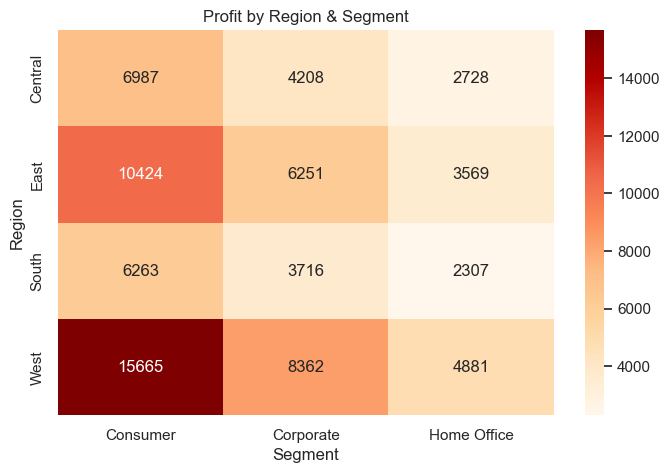

In [84]:
# Are there certain Customer Segments in underperforming Regions that need targeted marketing efforts?

plt.figure(figsize= (8, 5))
pivot = pd.pivot_table(df, values='Profit', index='Region', columns='Segment', aggfunc='sum')
sns.heatmap(pivot, annot=True, cmap="OrRd", fmt='.0f')
plt.title('Profit by Region & Segment')
plt.show()


The heatmap highlights how different customer segments perform across regions in terms of sales.
- The Consumer segment leads across all regions, especially in the West and East.
- Corporate performs best in the West, while it lags significantly in the South and East.
- The Home Office segment has a consistently lower presence, particularly weak in the South.

There is room to grow underrepresented segments in weaker regions. For instance, Corporate customers in the South could be re-engaged through B2B offers or relationship-based sales. Home Office segments in all regions, especially South and East, are prime candidates for targeted promotions or bundled product offerings

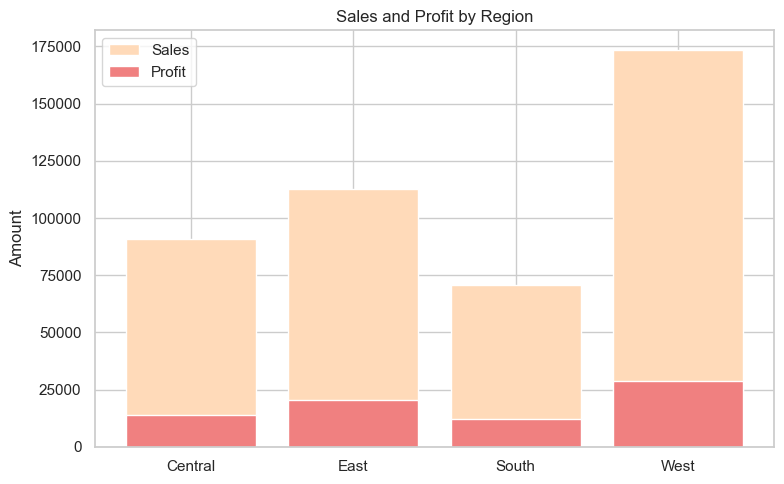

In [85]:
# Which Regions have untapped potential for expansion based on sales and profitability?

region_summary = df.groupby('Region')[['Sales', 'Profit']].sum().reset_index()

plt.figure(figsize=(8, 5))
plt.bar(region_summary['Region'], region_summary['Sales'], label='Sales', color='peachpuff')
plt.bar(region_summary['Region'], region_summary['Profit'], label='Profit', color='lightcoral')
plt.title('Sales and Profit by Region')
plt.ylabel('Amount')
plt.legend()
plt.tight_layout()
plt.show()


The stacked bar chart offers a comparative view of total revenue (sales + profit) by region.
- The West region stands out with the highest overall business value.
- East follows closely, with good sales but slightly lower profits compared to the West.
- South shows the smallest stack, confirming low combined contribution.

The West and East regions are already well-developed markets. Strategic pricing or cross-sell opportunities could help extract more value. The South represents an untapped market—a focus on improving profit margins and increasing customer base here could unlock new growth potential